### **Persistence in LangGraph**

> Make your agent workflows durable, resumable, and reliable.

<details>
<summary><strong>Why persistence matters</strong></summary>

- 🔁 Recover from crashes or restarts
- ⏳ Continue long-running agents without losing progress
- 🧠 Preserve conversation history and intermediate results
- 🐞 Replay and debug executions more easily

</details>

<details>
<summary><strong>Core concepts</strong></summary>

- **State**: Shared data flowing across nodes in the graph
- **Checkpointing**: Saving snapshots of the workflow state
- **Thread / Run ID**: Identifies a specific execution to resume
- **Resume capability**: Continues from the last saved checkpoint

</details>

### 🔄 Typical workflow
1. Define the graph state
2. Enable persistence or checkpointing
3. Run the workflow with a thread/session ID
4. Save progress after meaningful steps
5. Resume from the last checkpoint when needed

### ✅ Best practices
- Keep checkpoints lightweight and relevant
- Avoid storing sensitive or unnecessary data
- Use a durable storage backend for real-world reliability
- Monitor checkpoint size and retention over time

### 📝 Summary
Persistence transforms LangGraph workflows from one-shot runs into stateful, resilient, and production-ready systems.


**NOTE - FOR DEMO WE USE INMEMORY PERSISTENCE (LOCAL CPU MEMORY) BUT IN PRODUCTION THE IMPLEMENTATION IS SAME WITH PERSISTENCE LIKE POSTGRESS, SqliteSaver**

> *In-Memory (InMemorySaver): Fast and ideal for local testing, but volatile when the process terminates.*

> *SQLite / PostgreSQL / Redis: Durable, production-grade databases used to persist state safely across server crashes and reboots.*

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", max_output_tokens=1024)
load_dotenv()

True

In [3]:
# 1. Define State of Graph
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [4]:
# 2. Define the Functions/Node for Graph
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}


def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}



In [5]:
# 3. Define the graph 
graph = StateGraph(JokeState)

# 4. Add nodes to the graph
graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

# 5. Add edges to the graph
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

**Concept Clarity**

- **Checkpoint:** A complete state snapshot assigned a unique ID after a node finishes. (it helps to store/trace the each state value - both final and intermediate state)
- **Thread:** A distinct sequence of checkpoints organized by a unique thread_id (like an independent chat session - helpfull in multiple user at same time).
- **Pending writes:** Temporary records of successful node results stored if a later node fails, preventing duplicate work on resume

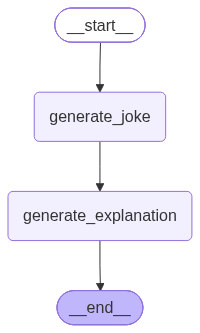

In [7]:
# 6. Create a checkpoint saver
checkpointer = InMemorySaver()

# Workflow execution with checkpointing
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [8]:
# 7. Define the config(unique session) & Invoke the workflow with a topic and a specific thread_id
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza get a ticket?\n\nBecause it was *double-parked*!',
 'explanation': 'This joke is a pun, which means it plays on words that sound alike but have different meanings. Here\'s the breakdown:\n\n*   **"Pizza"**: This is the subject of the joke.\n*   **"Double-parked"**: This is the punchline and where the pun lies.\n\nHere\'s how the pun works:\n\n1.  **Literal Meaning (Pizza Context):** When we talk about pizza, "double-parked" can refer to a pizza that has been ordered with **double the amount of toppings** or **double layers of cheese**. It\'s a common way to describe a very generous or rich pizza.\n\n2.  **Figurative Meaning (Traffic Context):** In the real world, "double-parking" is a traffic violation where a vehicle is parked parallel to another vehicle that is already parked at the curb, blocking traffic. This is illegal and often results in a ticket.\n\n**The Humor:**\n\nThe joke creates humor by taking the word "double-parked" and app

In [10]:
# get the state of the workflow after the first invocation for specific thread_id(config1)
workflow.get_state(config1)

#Note - this will retruns the final state of the workflow for specific thread_id.

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza get a ticket?\n\nBecause it was *double-parked*!', 'explanation': 'This joke is a pun, which means it plays on words that sound alike but have different meanings. Here\'s the breakdown:\n\n*   **"Pizza"**: This is the subject of the joke.\n*   **"Double-parked"**: This is the punchline and where the pun lies.\n\nHere\'s how the pun works:\n\n1.  **Literal Meaning (Pizza Context):** When we talk about pizza, "double-parked" can refer to a pizza that has been ordered with **double the amount of toppings** or **double layers of cheese**. It\'s a common way to describe a very generous or rich pizza.\n\n2.  **Figurative Meaning (Traffic Context):** In the real world, "double-parking" is a traffic violation where a vehicle is parked parallel to another vehicle that is already parked at the curb, blocking traffic. This is illegal and often results in a ticket.\n\n**The Humor:**\n\nThe joke creates humor by taking the word "dou

In [11]:
# get the full history of all the states of the specific thread_id(config1)
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza get a ticket?\n\nBecause it was *double-parked*!', 'explanation': 'This joke is a pun, which means it plays on words that sound alike but have different meanings. Here\'s the breakdown:\n\n*   **"Pizza"**: This is the subject of the joke.\n*   **"Double-parked"**: This is the punchline and where the pun lies.\n\nHere\'s how the pun works:\n\n1.  **Literal Meaning (Pizza Context):** When we talk about pizza, "double-parked" can refer to a pizza that has been ordered with **double the amount of toppings** or **double layers of cheese**. It\'s a common way to describe a very generous or rich pizza.\n\n2.  **Figurative Meaning (Traffic Context):** In the real world, "double-parking" is a traffic violation where a vehicle is parked parallel to another vehicle that is already parked at the curb, blocking traffic. This is illegal and often results in a ticket.\n\n**The Humor:**\n\nThe joke creates humor by taking the word "do

In [12]:
# Define the another config(unique session) & Invoke the workflow with a topic and a specific thread_id

config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti break up with the linguine?\n\nBecause he was too **saucy**!',
 'explanation': 'Here\'s the explanation for that joke:\n\nThe humor in this joke comes from a **pun**, which is a play on words.\n\n*   **"Saucy"** has two meanings:\n    1.  **Literally:** It refers to having sauce on it. Spaghetti and linguine are both types of pasta that are typically served with sauce.\n    2.  **Figuratively:** It means to be impudent, cheeky, or disrespectful, often in a playfully bold way.\n\nThe joke works because it takes the literal characteristic of spaghetti (being served with sauce) and uses it to explain a relationship problem (someone being "saucy" in their behavior). The spaghetti is breaking up with the linguine because the linguine\'s personality is too much like having too much sauce – it\'s overwhelming, overbearing, or perhaps just a bit too much to handle.\n\nSo, the punchline relies on the listener understanding both the literal mean

In [13]:
# get the final state for the config2
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti break up with the linguine?\n\nBecause he was too **saucy**!', 'explanation': 'Here\'s the explanation for that joke:\n\nThe humor in this joke comes from a **pun**, which is a play on words.\n\n*   **"Saucy"** has two meanings:\n    1.  **Literally:** It refers to having sauce on it. Spaghetti and linguine are both types of pasta that are typically served with sauce.\n    2.  **Figuratively:** It means to be impudent, cheeky, or disrespectful, often in a playfully bold way.\n\nThe joke works because it takes the literal characteristic of spaghetti (being served with sauce) and uses it to explain a relationship problem (someone being "saucy" in their behavior). The spaghetti is breaking up with the linguine because the linguine\'s personality is too much like having too much sauce – it\'s overwhelming, overbearing, or perhaps just a bit too much to handle.\n\nSo, the punchline relies on the listener understanding bo

In [14]:
# get the all state history for the config2
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti break up with the linguine?\n\nBecause he was too **saucy**!', 'explanation': 'Here\'s the explanation for that joke:\n\nThe humor in this joke comes from a **pun**, which is a play on words.\n\n*   **"Saucy"** has two meanings:\n    1.  **Literally:** It refers to having sauce on it. Spaghetti and linguine are both types of pasta that are typically served with sauce.\n    2.  **Figuratively:** It means to be impudent, cheeky, or disrespectful, often in a playfully bold way.\n\nThe joke works because it takes the literal characteristic of spaghetti (being served with sauce) and uses it to explain a relationship problem (someone being "saucy" in their behavior). The spaghetti is breaking up with the linguine because the linguine\'s personality is too much like having too much sauce – it\'s overwhelming, overbearing, or perhaps just a bit too much to handle.\n\nSo, the punchline relies on the listener understanding b

#### **Benefit of Persistance**

**1. Time Travel**

> The ability to navigate, inspect, and execute from past graph states using saved checkpoints.
>*Time travel functions through two main execution modes: Replay and Fork.*

**Replay Vs Forking**

| Action | How It Works | Primary Use Case |
|---|---|---|
| Replay | Resumes execution from a past checkpoint exactly as it was, re-running subsequent nodes. | Debugging and Auditing: Reproducing bugs or analyzing exactly why an agent took a wrong turn. |
| Forking | Modifies the state of a past checkpoint (e.g., changing an LLM message or variable) and starts a new branch. | What-If Scenarios: Changing a user's choice halfway through a complex multi-step form without restarting. |


In [16]:
#get state of specofic checkpoint_id for specific thread_id
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f19324a-bf79-617a-8000-3551f8527c59"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f19324a-bf79-617a-8000-3551f8527c59'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-08T12:28:33.843033+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19324a-bf73-6cdf-bfff-bb0e62f1a973'}}, tasks=(PregelTask(id='d69faff5-1e1a-1a67-c5ac-4438be4c973b', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza get a ticket?\n\nBecause it was *double-parked*!'}),), interrupts=())

In [17]:
# invoke specific state of the  workflow using the checkpoint_id for specific thread_id
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f19324a-bf79-617a-8000-3551f8527c59"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza get a job as a detective?\n\nBecause it was good at **crust**-ing cases!',
 'explanation': 'Here\'s the explanation for the joke:\n\nThe humor in this joke comes from a **pun**, which is a play on words that have similar sounds but different meanings.\n\n*   **"Crust"** in the joke refers to the outer layer of the pizza.\n*   **"Crust"** is also a slang term for the word **"cracking"** or **"solving"**. When someone is "cracking" a case, it means they are figuring it out and solving it.\n\nSo, the joke is funny because it uses the word "crust" to mean two different things:\n\n1.  The physical part of the pizza.\n2.  The act of solving a difficult problem or case.\n\nThe pizza is a detective because it\'s good at "crust-ing" (solving) cases, playing on the double meaning of the word.'}

In [ ]:
# now we see the time travel has happened and the state of the workflow is now reverted to the state of the specific checkpoint_id for specific thread_id
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza get a job as a detective?\n\nBecause it was good at **crust**-ing cases!', 'explanation': 'Here\'s the explanation for the joke:\n\nThe humor in this joke comes from a **pun**, which is a play on words that have similar sounds but different meanings.\n\n*   **"Crust"** in the joke refers to the outer layer of the pizza.\n*   **"Crust"** is also a slang term for the word **"cracking"** or **"solving"**. When someone is "cracking" a case, it means they are figuring it out and solving it.\n\nSo, the joke is funny because it uses the word "crust" to mean two different things:\n\n1.  The physical part of the pizza.\n2.  The act of solving a difficult problem or case.\n\nThe pizza is a detective because it\'s good at "crust-ing" (solving) cases, playing on the double meaning of the word.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19326b-1463-6641-8003-e460ae361088'}}, meta

**2. Updating State**

In [19]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f19324a-bf79-617a-8000-3551f8527c59", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19326f-f90c-6f1d-8001-139998e8431a'}}

In [20]:

list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19326f-f90c-6f1d-8001-139998e8431a'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-08T12:45:13.090651+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19324a-bf79-617a-8000-3551f8527c59'}}, tasks=(PregelTask(id='7a07e372-3f89-45a6-4539-6d694a24cfa0', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza get a job as a detective?\n\nBecause it was good at **crust**-ing cases!', 'explanation': 'Here\'s the explanation for the joke:\n\nThe humor in this joke comes from a **pun**, which is a play on words that have similar sounds but different meanings.\n\n*   **"Crust"** in the joke refers to the outer layer of t

In [22]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f19326f-f90c-6f1d-8001-139998e8431a"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa break up with the chutney?\n\nBecause he felt like he was always in a *spicy* relationship!',
 'explanation': 'Here\'s an explanation for the joke:\n\n*   **The Setup:** "Why did the samosa break up with the chutney?" This sets up a classic joke format where we\'re expecting a punchline that plays on the relationship between two food items.\n\n*   **The Punchline:** "Because he felt like he was always in a *spicy* relationship!"\n\n*   **The Wordplay:** The humor comes from the double meaning of the word "**spicy**".\n\n    1.  **Literal Meaning (Food):** Chutney is often spicy. A samosa, when dipped in chutney, experiences a spicy flavor. So, in a literal sense, their "relationship" (being eaten together) is indeed spicy.\n    2.  **Figurative Meaning (Relationships):** In human relationships, "spicy" can mean exciting, passionate, or sometimes, volatile and dramatic. The joke is humorously applying this human relationship term to the f

In [23]:

list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa break up with the chutney?\n\nBecause he felt like he was always in a *spicy* relationship!', 'explanation': 'Here\'s an explanation for the joke:\n\n*   **The Setup:** "Why did the samosa break up with the chutney?" This sets up a classic joke format where we\'re expecting a punchline that plays on the relationship between two food items.\n\n*   **The Punchline:** "Because he felt like he was always in a *spicy* relationship!"\n\n*   **The Wordplay:** The humor comes from the double meaning of the word "**spicy**".\n\n    1.  **Literal Meaning (Food):** Chutney is often spicy. A samosa, when dipped in chutney, experiences a spicy flavor. So, in a literal sense, their "relationship" (being eaten together) is indeed spicy.\n    2.  **Figurative Meaning (Relationships):** In human relationships, "spicy" can mean exciting, passionate, or sometimes, volatile and dramatic. The joke is humorously applying this human relati

**3. Fault Taulrance**
> Prevents workflows from failing due to transient network errors, API timeouts, or unhandled exceptions.

**Three Core premitive for Fault taulrance**

[ Node Fails ] ──> [ Retry Policy (Backoff) ] ──> [ Timeout Policy (Cap) ] ──> [ Error Handler (Recovery Node) ]

> NOTE - Here we intrupt the run to create artificial fault taulrance when it take 30 sec pause on step 2(added intensionally)

In [4]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [5]:
# 2. Define steps
import time
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [6]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)


In [1]:

# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...


NameError: name 'graph' is not defined

**4. HITL - Human in the Loop**

Some use case require human approval and say workflow is done with their step and waiting for the Human Input but it may possible User give input after long time and till that running the workflow is not good, so the better approach is to use Checkpointer, by this workflow pause the run when HITL come and it will not run till the input and once user enter the input the workflow will resume at the same state where it dropped without any memory loss.